# Shallow 1 Dimension Convolutional Network

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from utils import load_data, evaluate_forecast, plot_results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, Flatten, MaxPooling1D

In [ ]:
df = load_data()

In [ ]:

def build_cnn_model(input_dim, window_size):
    """
    Costruisce una Shallow 1D CNN.
    input_dim: solitamente 1 (numero di features/variabili)
    window_size: lunghezza della sequenza (es. 5)
    """
    model = Sequential([
        # L'input shape deve essere (Window_Size, Features)
        Input(shape=(window_size, input_dim)),
        
        # Layer Convoluzionale: "Lente" che scorre
        # filters=16: cerca 16 tipi di pattern diversi
        # kernel_size=3: guarda 3 anni alla volta
        Conv1D(filters=16, kernel_size=3, activation='relu', padding='same'),
        
        # Pooling (Opzionale su finestre corte, ma proviamo): riduce la dimensione
        MaxPooling1D(pool_size=2), 
        
        # Appiattisce tutto per la parte finale
        Flatten(),
        
        # Parte densa finale (simile al MLP) per la decisione
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
    return model

INIZIO TRAINING CNN ENSEMBLE

Dataset: Originale (Shape: (47, 5, 1))
CNN ENSEMBLE RMSE: 2.5006

Dataset: Step Function (Shape: (515, 5, 1))
CNN ENSEMBLE RMSE: 2.7856

Dataset: Linear + Jitter (Shape: (515, 5, 1))
CNN ENSEMBLE RMSE: 2.7778

--- RISULTATI CNN ---


,Dataset,RMSE_CNN,MAE_CNN
0,Originale,2.500619,2.429782
2,Linear + Jitter,2.777820,2.715867
1,Step Function,2.785615,2.723506


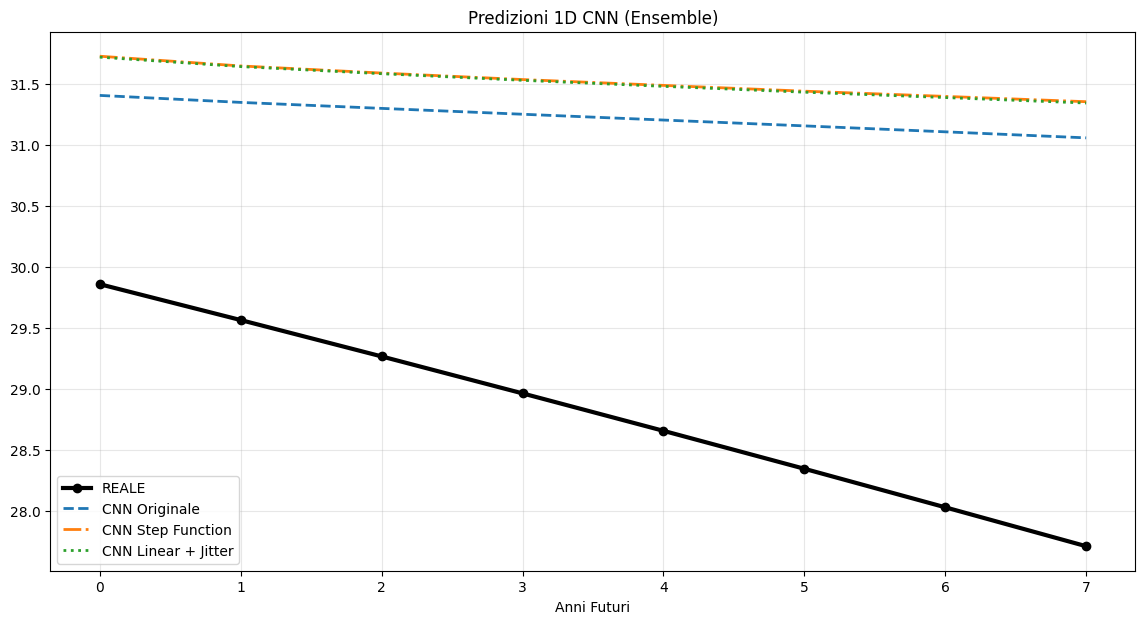

In [ ]:
N_RUNS_CNN = 5
seeds = [42, 123, 456, 789, 1000]
input_features = 1 # Abbiamo solo la 'Value'

results_cnn = {}
metrics_cnn = []

print(f"INIZIO TRAINING CNN ENSEMBLE")

for name, (curr_X, curr_y) in training_sets.items():
    
    # *** RESHAPE PER CNN ***
    # Da (N, 5) diventa (N, 5, 1)
    X_cnn = curr_X.reshape((curr_X.shape[0], curr_X.shape[1], 1))
    X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    print(f"\nDataset: {name} (Shape: {X_cnn.shape})")
    
    all_predictions = np.zeros((N_RUNS_CNN, len(X_test)))
    
    for i in range(N_RUNS_CNN):
        reset_seeds(seeds[i]) 
        
        model = build_cnn_model(input_features, WINDOW_SIZE)
        
        history = model.fit(
            X_cnn, curr_y,
            epochs=150, # Le CNN spesso convergono prima
            batch_size=16,
            validation_data=(X_test_cnn, y_test),
            verbose=0,
            callbacks=[early_stop, reduce_lr],
            shuffle=True
        )
        
        pred_scaled = model.predict(X_test_cnn, verbose=0)
        pred_real = scaler.inverse_transform(pred_scaled).flatten()
        all_predictions[i, :] = pred_real

    # Media Ensemble
    ensemble_pred = np.mean(all_predictions, axis=0)
    
    # Metriche
    rmse_ens = np.sqrt(mean_squared_error(y_test_real, ensemble_pred))
    mae_ens = mean_absolute_error(y_test_real, ensemble_pred)
    
    results_cnn[name] = ensemble_pred
    metrics_cnn.append({"Dataset": name, "RMSE_CNN": rmse_ens, "MAE_CNN": mae_ens})
    
    print(f"CNN ENSEMBLE RMSE: {rmse_ens:.4f}")

# --- CONFRONTO FINALE MLP vs CNN ---
df_cnn = pd.DataFrame(metrics_cnn).sort_values(by="RMSE_CNN")
print("\n--- RISULTATI CNN ---")
display(df_cnn)

# Plot CNN
plt.figure(figsize=(14, 7))
plt.plot(range(len(y_test_real)), y_test_real, 'o-', label='REALE', color='black', linewidth=3)
styles = ['--', '-.', ':']
for i, (name, preds) in enumerate(results_cnn.items()):
    plt.plot(range(len(y_test_real)), preds, styles[i], label=f'CNN {name}', linewidth=2)

plt.title("Predizioni 1D CNN (Ensemble)")
plt.xlabel("Anni Futuri")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()